# Iris

## Importando as bibliotecas

In [14]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
from plotnine import ggplot, aes, geom_point, geom_line, geom_histogram, geom_density, facet_wrap, labs, theme_minimal
from janitor import clean_names
import matplotlib.pyplot as plt

## Conheçendo o Dataset Iris

O dataset Iris é um conjunto de dados clássico em aprendizado de máquina e estatística, frequentemente utilizado para demonstração de algoritmos de classificação. Ele contém informações sobre três espécies diferentes de íris (Iris setosa, Iris versicolor e Iris virginica) com quatro características medidas: comprimento e largura das sépalas e pétalas.

Ele é um dataset tão clássico que foi utilizado em diversos estudos e tutoriais, incluindo o trabalho de R.A. Fisher em 1936, que introduziu o conceito de análise discriminante linear. @unwin_iris_2021

Inclusive faz parte dos datasets padrão da biblioteca Scikit-learn, facilitando seu acesso para análise e modelagem.

### Aula de Inglês

- Petal: Pétala
- Sepal: Sépala
- Length: Comprimento
- Width: Largura
- Species: Espécie

### Um pouco mais de conhecimento

Se você ta curioso apra saber a diferença entre as espécies como também a diferença entre sépala e pétala, aqui vai:  
![Diferença entre sépala e pétala](../../static/iris-tipos.png)

- Será que é possível diferenciar as espécies de íris com base nas medidas das sépalas e pétalas?
- Quais características (comprimento e largura das sépalas e pétalas) são mais eficazes para distinguir entre as espécies de íris?
- Conseguimos prever a espécie de uma íris com base nas medidas das sépalas e pétalas usando um moadelo de classificação?

### Objetivos do estudo

**Hipótese:** Acreditamos ser possível diferenciar as espécies de íris com base nas medidas das sépalas e pétalas.

**Objetivos:**

- [x] Quais características (comprimento e largura das sépalas e pétalas) são mais eficazes para distinguir entre as espécies de íris?
- [x] Conseguimos prever a espécie de uma íris com base nas medidas das sépalas e pétalas usando um modelo de classificação?






# Hands-On

## Carregando o dataset

In [15]:

iris = load_iris() # Aqui temos um conjunto de dados embutido no scikit-learn
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris['target_name'] = df_iris['target'].map({0: iris.target_names[0], 1: iris.target_names[1], 2: iris.target_names[2]})
df_iris.drop(columns=['target'], inplace=True)
df_iris['target_name'] = pd.Categorical(df_iris['target_name'])
df_iris.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target_name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [16]:
df_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   target_name        150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB


Como podemos ver temos as medidas do comprimento e largura das sépalas e pétalas de três espécies diferentes de íris: Setosa, Versicolor e Virginica.

## Análise Exploratória dos Dados

### Balanceamento das classes

Temos um conjunto de dados perfeitamente balanceado, com 50 amostras para cada espécie de íris.

In [17]:
df_iris['target_name'].value_counts()


target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Estatísticas descritivas

In [18]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


###  Distribuições

In [19]:
df_long =df_iris.melt(id_vars='target_name')
df_long.head()

,target_name,variable,value
0,setosa,sepal length (cm),5.1
1,setosa,sepal length (cm),4.9
2,setosa,sepal length (cm),4.7
3,setosa,sepal length (cm),4.6
4,setosa,sepal length (cm),5.0


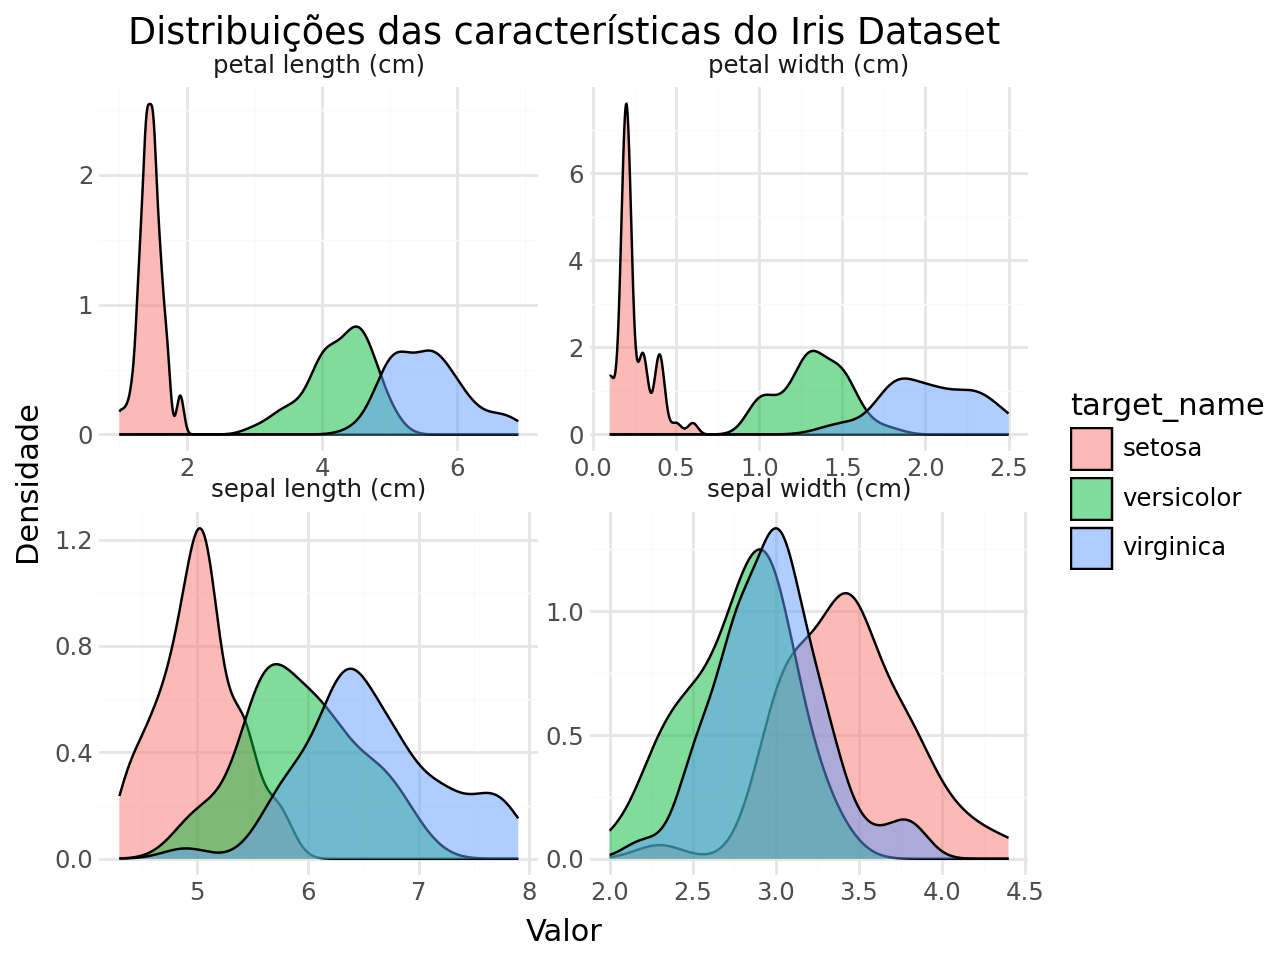

In [20]:
ggplot(df_long, aes(x='value', fill='target_name')) + \
    geom_density(alpha=0.5) + \
    facet_wrap('~variable', scales='free') + \
    labs(title='Distribuições das características do Iris Dataset', x='Valor', y='Densidade') + \
    theme_minimal()

::: {.callout-tip}
## Primeiras Impressões

Olhando as distribuições o tamanho das pétalas (petal length e petal width) parecem ser as características mais discriminatórias entre as espécies, especialmente para a espécie Setosa que se destaca claramente das outras duas.

Enquanro que as sépalas (sepal length e sepal width) mostram mais sobreposição entre as espécies, o que pode dificultar a distinção entre elas com base nessas características.

:::

## Brainstorming

Como estamos lidando com um problema de classificação temos algumas opções de algoritmos que podemos utilizar, a lista a seguir apresenta os algoritmos do mais simples aos mais complexos:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Trees

Esta será a nossa próxima etapa: construir modelos preditivos para classificar as espécies de íris com base nas medidas das sépalas e pétalas.

### Preparando os dados para modelagem

In [58]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [61]:
X = clean_names(df_iris, strip_underscores=True)
X_features = X.drop(columns=['target_name'])
y_target = X['target_name']
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.5, random_state=42)

### Regressão Logística

$$ P(Y=i|X) = \frac{e^{\beta_{0i} + \beta_{1i}X_1 + \beta_{2i}X_2 + ... + \beta_{ki}X_k}}{1 + \sum_{j=1}^{m-1} e^{\beta_{0j} + \beta_{1j}X_1 + \beta_{2j}X_2 + ... + \beta_{kj}X_k}} $$

In [62]:
from sklearn.linear_model import LogisticRegression

In [72]:
reglog_model = LogisticRegression()
reglog_model.fit(X_train, y_train)
y_pred = reglog_model.predict(X_test)

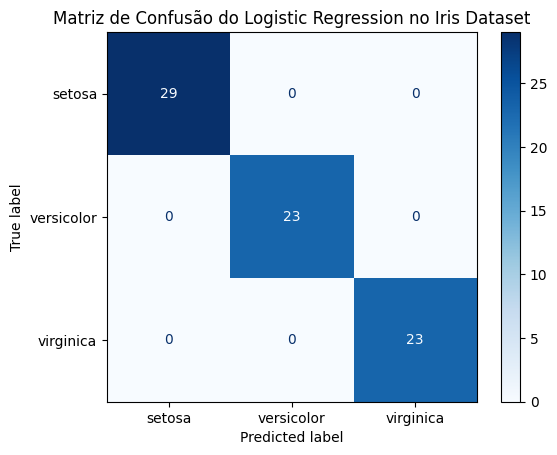

In [74]:
disp_reglog = ConfusionMatrixDisplay.from_estimator(reglog_model, X_test, y_pred, cmap='Blues', normalize=None)
disp_reglog.ax_.set_title('Matriz de Confusão do Logistic Regression no Iris Dataset')
plt.show()

### K-Nearest Neighbors (KNN)

$$ P(Y=i|X) = \frac{K_i}{K} $$

In [65]:
from sklearn.neighbors import KNeighborsClassifier

In [66]:
knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        29
  versicolor       1.00      1.00      1.00        23
   virginica       1.00      1.00      1.00        23

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



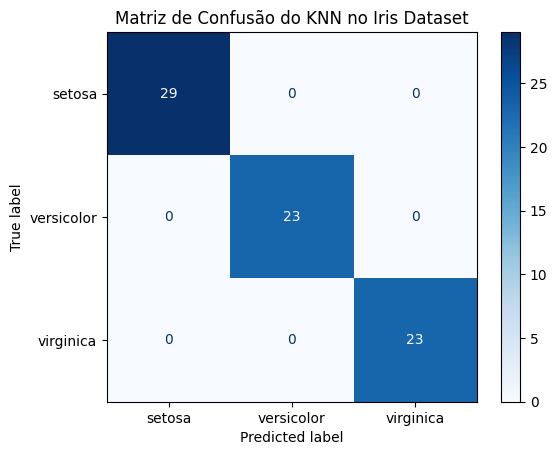

In [67]:
disp = ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test, cmap='Blues', normalize=None)
disp.ax_.set_title('Matriz de Confusão do KNN no Iris Dataset')
plt.show()

### Árvores de Decisão

In [68]:
from sklearn.tree import DecisionTreeClassifier

In [75]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        29
  versicolor       1.00      1.00      1.00        23
   virginica       1.00      1.00      1.00        23

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



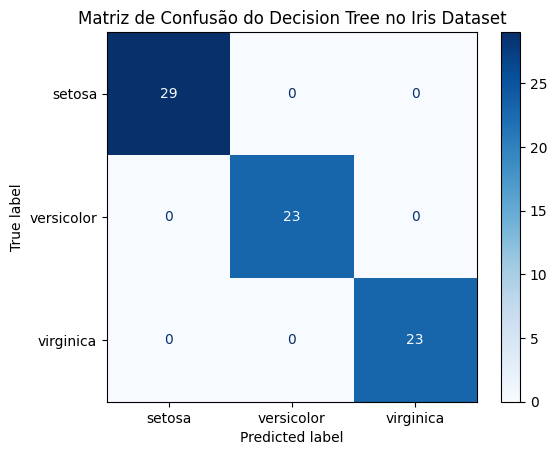

In [76]:
disp = ConfusionMatrixDisplay.from_estimator(tree_model, X_test, y_test, cmap='Blues', normalize=None)
disp.ax_.set_title('Matriz de Confusão do Decision Tree no Iris Dataset')
plt.show()

## Referências {.unnumbered}

::: {#refs}
:::